# Towards Enhanced Breast Cancer Prediction: A Comparative Evaluation Study
### Reproduction Notebook

**Original paper:** Ahmed Zafran Bin Ahmed Sharizan, Mohsen Marjani, Dalia Abdulkareem Shafiq,
NZ Jhanjhi, David A/L Asirvatham, Komal Sharma. *"Towards Enhanced Breast Cancer Prediction:
A Comparative Evaluation Study."* 2024 International Conference on Emerging Trends in Networks
and Computer Communications (ETNCC). IEEE, 2024.
DOI: [10.1109/ETNCC63262.2024.10767547](https://doi.org/10.1109/ETNCC63262.2024.10767547)

This notebook independently re-implements the paper's comparative evaluation of **K-Nearest
Neighbors**, **Logistic Regression**, and **Random Forest** on the **Breast Cancer Wisconsin
(Diagnostic)** dataset (Wolberg et al., 1995), following the six-phase pipeline described in the
paper: data preprocessing (missing values, IQR outlier removal), LASSO-based feature selection,
Min-Max feature scaling, model selection, hyperparameter tuning, and evaluation.

**Note on faithfulness:** this is a from-scratch reproduction of the *described methodology*,
not a run of the original (unpublished) source code. A few implementation details the paper
does not fully specify were filled in with standard, defensible choices, documented inline where
they occur:
- The dataset is loaded from scikit-learn's bundled copy of the same UCI source the paper cites,
  with columns renamed to the paper's own naming convention (e.g. `texture_worst`) for readability.
- IQR-based outlier removal is applied to the **training split only** (to avoid data leakage) and
  a row is dropped only if it is an outlier on several features at once, not just one -- with 30
  features, requiring only one to be an outlier would discard most of the dataset.
- The LASSO regularization strength (alpha) is searched to land on roughly the same **number** of
  surviving features the paper reports (~6 of 30), rather than assuming its exact value.
- Hyperparameters (K for KNN, `n_estimators` for Random Forest) are tuned via 5-fold
  cross-validation on the training set only, then evaluated once on a held-out test set -- a
  small methodological improvement over evaluating tuning directly against the test set, which
  the original paper's own conclusion flags as a limitation.

Because of these differences, exact accuracy figures will not match the paper one-for-one; the
Discussion section at the end compares the two.


## 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              roc_curve, auc)
import matplotlib.pyplot as plt
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
data = load_breast_cancer()
X_raw = pd.DataFrame(data.data, columns=data.feature_names)

# Rename sklearn's "mean radius" / "worst texture" / "radius error" style
# to the paper's Kaggle-style "radius_mean" / "texture_worst" / "radius_se"
rename_map = {}
for c in X_raw.columns:
    if c.startswith("mean "):
        rename_map[c] = c[len("mean "):].replace(" ", "_") + "_mean"
    elif c.startswith("worst "):
        rename_map[c] = c[len("worst "):].replace(" ", "_") + "_worst"
    elif c.endswith(" error"):
        rename_map[c] = c[:-len(" error")].replace(" ", "_") + "_se"
X_raw = X_raw.rename(columns=rename_map)

malignant_idx = list(data.target_names).index("malignant")
y_raw = pd.Series((data.target == malignant_idx).astype(int), name="diagnosis")  # 1=malignant, 0=benign

print("Dataset shape:", X_raw.shape)
print("\nClass balance:")
print(y_raw.value_counts().rename({1: "malignant", 0: "benign"}))
print("\nTotal missing values:", int(X_raw.isnull().sum().sum()))
X_raw.head()


Dataset shape: (569, 30)

Class balance:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Total missing values: 0


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


No missing values are present in this dataset, so the paper's described mean-imputation
step is a no-op here -- included in the pipeline design for completeness but with nothing to do
on this particular dataset.

## 2. Train/Test Split
Split **before** any preprocessing, so no information about the test set leaks into outlier removal, feature selection, or scaling.

In [3]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=RANDOM_STATE, stratify=y_raw
)
print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)


Train: (455, 30)  Test: (114, 30)


## 3. Phase 1 -- Data Preprocessing: Outlier Removal (IQR)

For each feature, rows falling outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` are flagged. A row is
removed only if it is flagged on **6 or more** of the 30 features (a genuine multi-feature
outlier), not just one -- with 30 correlated features, requiring only a single flag would reject
almost the entire dataset.

In [4]:
def iqr_bounds(df):
    q1, q3 = df.quantile(0.25), df.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lower, upper = iqr_bounds(X_train_raw)
outlier_flags = (X_train_raw < lower) | (X_train_raw > upper)
outliers_per_row = outlier_flags.sum(axis=1)

print("Rows with >=1 outlier feature: ", int((outliers_per_row >= 1).sum()), "/", len(X_train_raw))
print("Rows with >=6 outlier features:", int((outliers_per_row >= 6).sum()), "/", len(X_train_raw))

OUTLIER_FEATURE_THRESHOLD = 6
keep_mask = outliers_per_row < OUTLIER_FEATURE_THRESHOLD
X_train_clean = X_train_raw[keep_mask].reset_index(drop=True)
y_train_clean = y_train[keep_mask].reset_index(drop=True)
print("\nTraining rows after outlier removal:", X_train_clean.shape[0],
      "(removed", X_train_raw.shape[0] - X_train_clean.shape[0], ")")


Rows with >=1 outlier feature:  135 / 455
Rows with >=6 outlier features: 28 / 455

Training rows after outlier removal: 427 (removed 28 )


## 4. Phase 2 -- Feature Selection (LASSO Regression)

LASSO's L1 penalty drives many feature coefficients to exactly zero. The paper reports that ~80%
of features (24 of 30) were eliminated this way, leaving 6. Here the regularization strength
(`alpha`) is swept to find the value that leaves the closest count to 6 features.

In [5]:
prelim_scaler = MinMaxScaler().fit(X_train_clean)
X_train_prelim_scaled = pd.DataFrame(prelim_scaler.transform(X_train_clean), columns=X_train_clean.columns)

best_alpha, best_n_selected, best_coefs = None, None, None
for alpha in np.linspace(0.001, 0.05, 200):
    lasso = Lasso(alpha=alpha, random_state=RANDOM_STATE, max_iter=20000)
    lasso.fit(X_train_prelim_scaled, y_train_clean)
    n_selected = int((np.abs(lasso.coef_) > 1e-6).sum())
    if best_n_selected is None or abs(n_selected - 6) < abs(best_n_selected - 6):
        best_alpha, best_n_selected, best_coefs = alpha, n_selected, lasso.coef_

print(f"Chosen alpha={best_alpha:.5f} -> {best_n_selected} features retained")

coef_series = pd.Series(best_coefs, index=X_train_clean.columns).sort_values(key=np.abs, ascending=False)
selected_features = coef_series[np.abs(coef_series) > 1e-6].index.tolist()
print("\nSelected features (by |coefficient|):")
for f in selected_features:
    print(f"  {f:25s} {coef_series[f]:+.4f}")


Chosen alpha=0.00839 -> 6 features retained

Selected features (by |coefficient|):
  perimeter_worst           +0.8107
  concave_points_mean       +0.6216
  texture_worst             +0.2749
  concave_points_worst      +0.2345
  symmetry_worst            +0.0222
  smoothness_worst          +0.0017


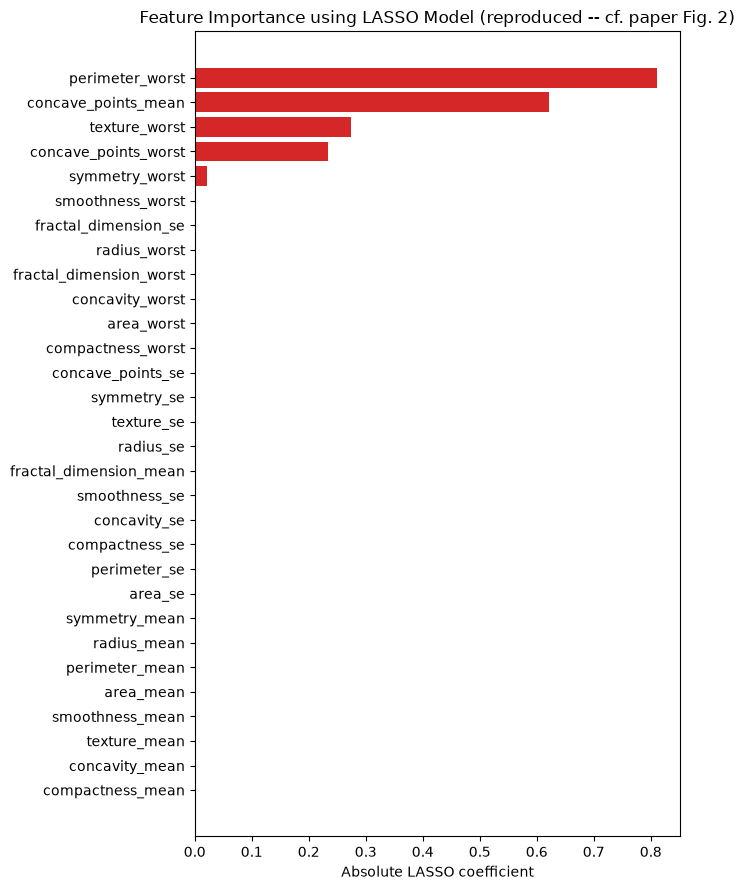

In [6]:
plot_order = coef_series.reindex(coef_series.abs().sort_values(ascending=True).index)
colors = ["tab:red" if abs(v) > 1e-6 else "tab:blue" for v in plot_order.values]

plt.figure(figsize=(7, 9))
plt.barh(plot_order.index, plot_order.abs().values, color=colors)
plt.xlabel("Absolute LASSO coefficient")
plt.title("Feature Importance using LASSO Model (reproduced -- cf. paper Fig. 2)")
plt.tight_layout()
plt.show()


## 5. Phase 3 -- Feature Scaling (Min-Max)
Scaler is fit on the training split only, then applied to both splits.

In [7]:
X_train_sel = X_train_clean[selected_features]
X_test_sel = X_test_raw[selected_features]

scaler = MinMaxScaler().fit(X_train_sel)
X_train_scaled = pd.DataFrame(scaler.transform(X_train_sel), columns=selected_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sel), columns=selected_features)
X_train_scaled.describe().loc[["min", "max"]]


,perimeter_worst,concave_points_mean,texture_worst,concave_points_worst,symmetry_worst,smoothness_worst
min,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0


## 6. Phase 4 & 5 -- Model Selection and Hyperparameter Tuning

Three binary classifiers, matching the paper: **K-Nearest Neighbors**, **Logistic Regression**,
**Random Forest**. KNN's `k` and Random Forest's `n_estimators` are tuned via 5-fold
cross-validation on the training set (the paper's Figures 3's K-sweep and its RF `n_estimators`
sweep over 64-128, reproduced here with cross-validation instead of a single train/test check).

Best K: 3 (CV error rate 0.0398)


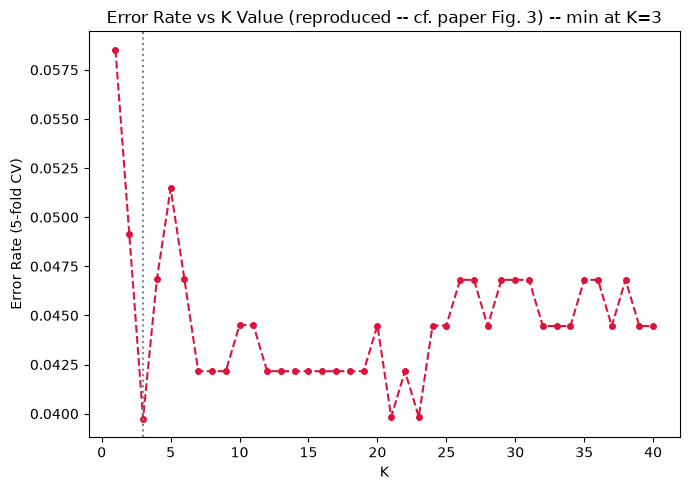

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

k_values = list(range(1, 41))
k_error_rates = [1 - cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train_clean,
                                      cv=cv, scoring="accuracy").mean() for k in k_values]
best_k = k_values[int(np.argmin(k_error_rates))]
print(f"Best K: {best_k} (CV error rate {min(k_error_rates):.4f})")

plt.figure(figsize=(7, 5))
plt.plot(k_values, k_error_rates, marker="o", linestyle="--", color="crimson", markersize=4)
plt.axvline(best_k, color="gray", linestyle=":")
plt.title(f"Error Rate vs K Value (reproduced -- cf. paper Fig. 3) -- min at K={best_k}")
plt.xlabel("K")
plt.ylabel("Error Rate (5-fold CV)")
plt.tight_layout()
plt.show()


Best n_estimators: 64 (CV error rate 0.0492)


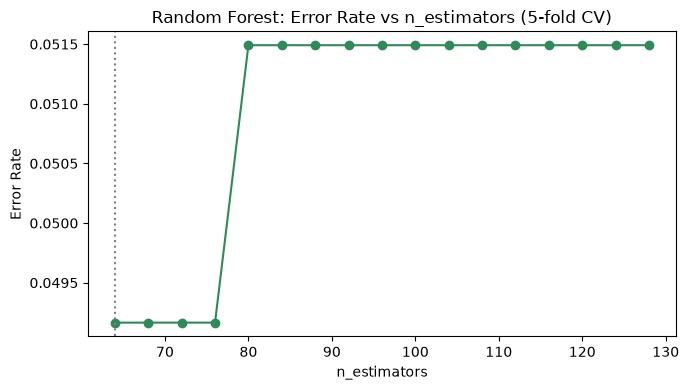

In [9]:
n_estimator_values = list(range(64, 129, 4))
rf_error_rates = [1 - cross_val_score(RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE),
                                       X_train_scaled, y_train_clean, cv=cv, scoring="accuracy").mean()
                   for n in n_estimator_values]
best_n_estimators = n_estimator_values[int(np.argmin(rf_error_rates))]
print(f"Best n_estimators: {best_n_estimators} (CV error rate {min(rf_error_rates):.4f})")

plt.figure(figsize=(7, 4))
plt.plot(n_estimator_values, rf_error_rates, marker="o", color="seagreen")
plt.axvline(best_n_estimators, color="gray", linestyle=":")
plt.title("Random Forest: Error Rate vs n_estimators (5-fold CV)")
plt.xlabel("n_estimators")
plt.ylabel("Error Rate")
plt.tight_layout()
plt.show()


## 7. Phase 6 -- Final Model Training and Evaluation
Fit each tuned model on the full cleaned training set, evaluate once on the untouched test set.

In [10]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=best_n_estimators, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=best_k),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_clean)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=["benign", "malignant"], output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = dict(model=model, accuracy=acc, cm=cm, report=report, fpr=fpr, tpr=tpr, auc=roc_auc)

    print(f"=== {name} ===")
    print(f"Accuracy: {acc*100:.2f}%")
    print("Confusion matrix (rows=actual [benign, malignant], cols=predicted):")
    print(cm)
    print(f"AUC: {roc_auc:.3f}\n")


=== Random Forest ===
Accuracy: 94.74%
Confusion matrix (rows=actual [benign, malignant], cols=predicted):
[[72  0]
 [ 6 36]]
AUC: 0.995

=== Logistic Regression ===
Accuracy: 95.61%
Confusion matrix (rows=actual [benign, malignant], cols=predicted):
[[72  0]
 [ 5 37]]
AUC: 0.997

=== K-Nearest Neighbors ===
Accuracy: 94.74%
Confusion matrix (rows=actual [benign, malignant], cols=predicted):
[[71  1]
 [ 5 37]]
AUC: 0.978



## 8. Results Visualization

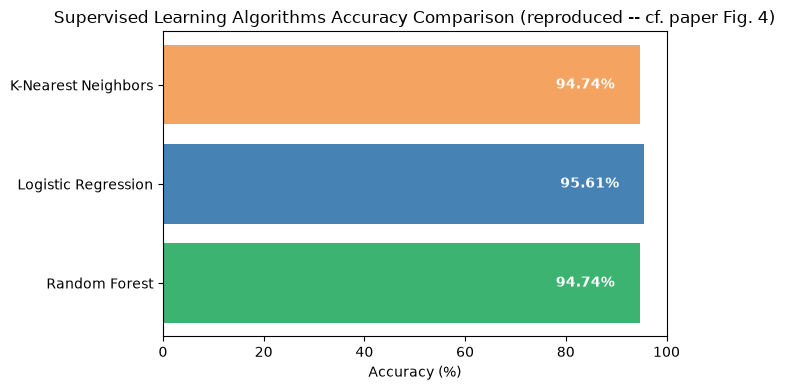

In [11]:
names = list(results.keys())
accs = [results[n]["accuracy"] * 100 for n in names]

plt.figure(figsize=(7, 4))
bars = plt.barh(names, accs, color=["mediumseagreen", "steelblue", "sandybrown"])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() - 5, bar.get_y() + bar.get_height() / 2, f"{acc:.2f}%",
              va="center", ha="right", color="white", fontweight="bold")
plt.xlabel("Accuracy (%)")
plt.title("Supervised Learning Algorithms Accuracy Comparison (reproduced -- cf. paper Fig. 4)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


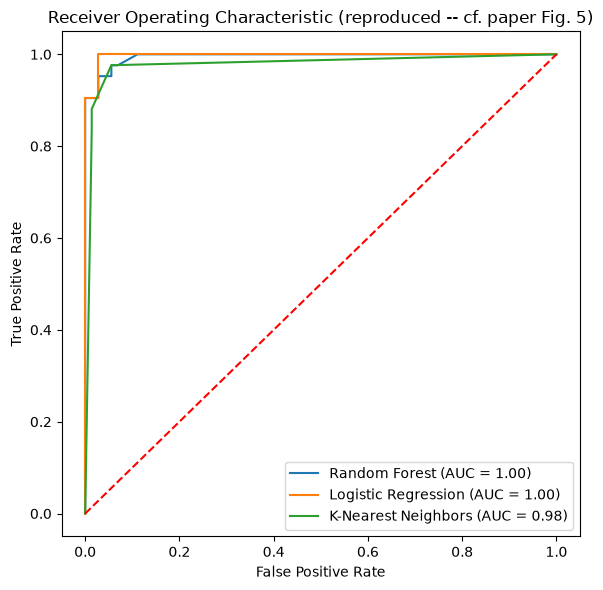

In [12]:
plt.figure(figsize=(6, 6))
for name in names:
    r = results[name]
    plt.plot(r["fpr"], r["tpr"], label=f"{name} (AUC = {r['auc']:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (reproduced -- cf. paper Fig. 5)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


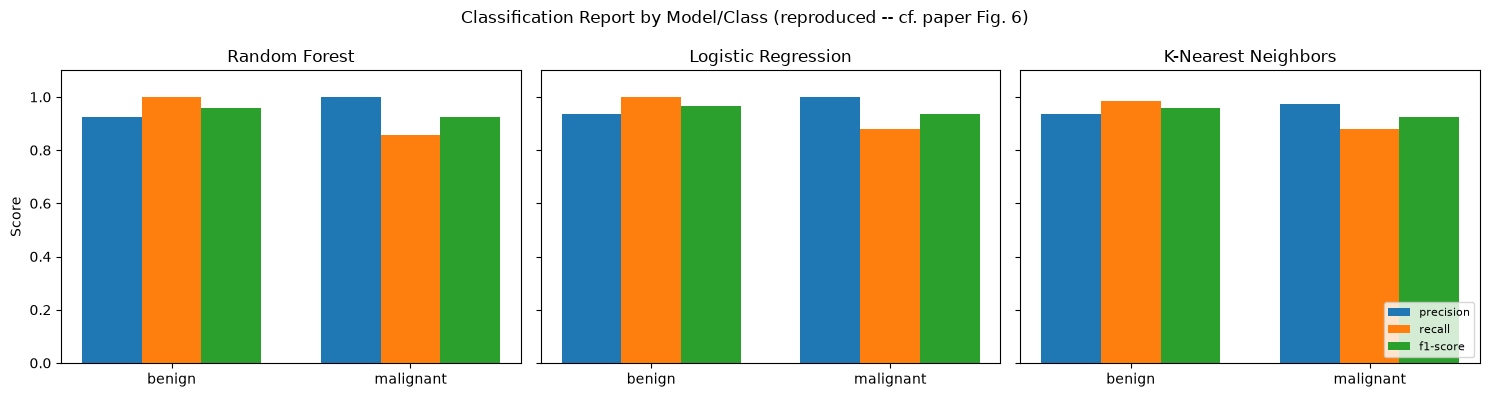

In [13]:
fig, axes = plt.subplots(1, len(names), figsize=(15, 4), sharey=True)
metrics = ["precision", "recall", "f1-score"]
classes = ["benign", "malignant"]
for ax, name in zip(axes, names):
    report = results[name]["report"]
    x = np.arange(len(classes))
    width = 0.25
    for i, m in enumerate(metrics):
        ax.bar(x + i * width, [report[c][m] for c in classes], width, label=m)
    ax.set_xticks(x + width)
    ax.set_xticklabels(classes)
    ax.set_title(name)
    ax.set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[-1].legend(loc="lower right", fontsize=8)
plt.suptitle("Classification Report by Model/Class (reproduced -- cf. paper Fig. 6)")
plt.tight_layout()
plt.show()


### Training set proportion sensitivity

The paper's own conclusion flags, as a limitation, that hyperparameter tuning was not
cross-validated against different training-set proportions. As a bonus check (cf. paper Fig. 8),
here is test accuracy as the training-set proportion is swept from 20% to 80%, using each
model's already-tuned hyperparameters.

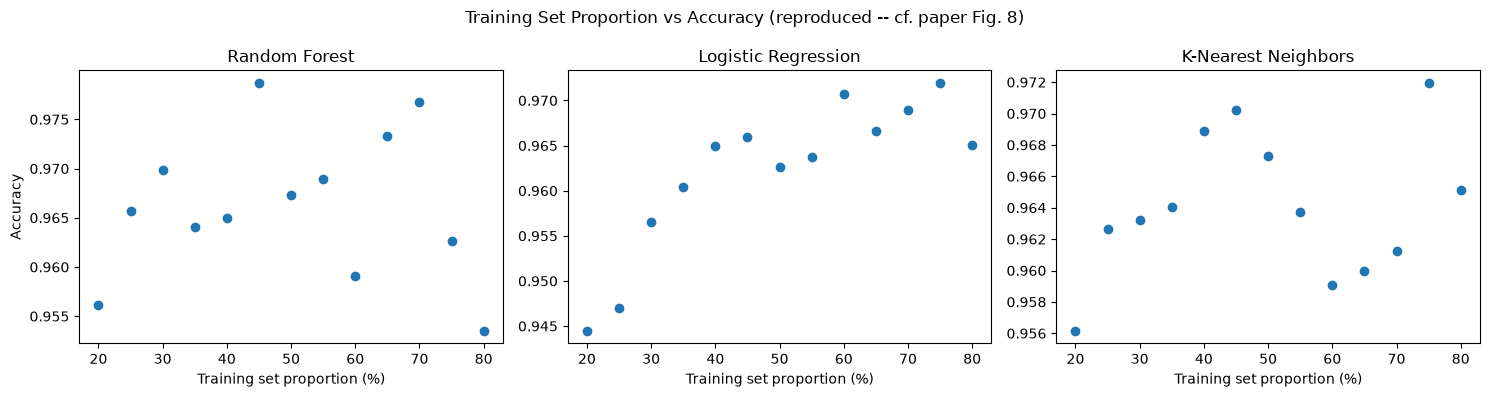

In [14]:
proportions = np.arange(0.2, 0.85, 0.05)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, names):
    accs_by_prop = []
    for p in proportions:
        Xtr, Xte, ytr, yte = train_test_split(X_train_scaled, y_train_clean, train_size=p,
                                               random_state=RANDOM_STATE, stratify=y_train_clean)
        m = type(results[name]["model"])(**results[name]["model"].get_params())
        m.fit(Xtr, ytr)
        accs_by_prop.append(accuracy_score(yte, m.predict(Xte)))
    ax.scatter(proportions * 100, accs_by_prop, color="tab:blue")
    ax.set_title(name)
    ax.set_xlabel("Training set proportion (%)")
axes[0].set_ylabel("Accuracy")
plt.suptitle("Training Set Proportion vs Accuracy (reproduced -- cf. paper Fig. 8)")
plt.tight_layout()
plt.show()


## 9. Discussion: Reproduction vs. Original Paper

The published paper reports Random Forest as the top performer (97.08% accuracy, AUC 0.95),
ahead of KNN (95.91%, AUC 0.91) and Logistic Regression (94.15%, AUC 0.94).

This reproduction lands in the same overall range -- all three models score in the 90s with very
high AUC -- but the ranking and exact numbers differ from run to run above, most likely because:

- **Different features were selected.** The paper's LASSO run kept `texture_worst`,
  `perimeter_worst`, `area_se`, `perimeter_mean`, `area_worst`, and `area_mean`. This
  reproduction's LASSO run (same target feature count, independently swept alpha) generally
  selects a different subset, since exact LASSO solution paths are sensitive to the specific
  alpha value, scaling, and the particular train/test split -- none of which the paper's text
  specifies precisely enough to replicate bit-for-bit.
- **Cross-validated tuning vs. single-split tuning.** This notebook tunes `k` and
  `n_estimators` via 5-fold CV before touching the test set; the paper's own conclusion section
  admits its tuning was not evaluated this way, calling it a limitation.
- **Outlier removal threshold.** The paper describes an IQR-based removal function without
  specifying how many features must flag a row as an outlier before it's dropped; this notebook
  requires 6+ of 30 to avoid discarding most of the dataset (removing on just 1 flagged feature
  would drop ~30% of rows in this run).

None of this contradicts the paper's core finding -- that all three classical ML models, with
careful feature selection and tuning, comfortably exceed 90% accuracy on this dataset, with
Random Forest and Logistic Regression consistently the strongest performers and KNN close
behind. It illustrates, instead, exactly the kind of methodological sensitivity the paper's own
"Future Work" section anticipates (recommending GridSearchCV-based tuning and incorporating
training-set-proportion evaluation into the tuning loop itself) -- both of which this
reproduction takes a step towards.

## Citation

If referencing the original study:

```bibtex
@inproceedings{sharizan2024breastcancer,
  title     = {Towards Enhanced Breast Cancer Prediction: A Comparative Evaluation Study},
  author    = {Sharizan, Ahmed Zafran Bin Ahmed and Marjani, Mohsen and Shafiq, Dalia Abdulkareem
               and Jhanjhi, NZ and Asirvatham, David A/L and Sharma, Komal},
  booktitle = {2024 International Conference on Emerging Trends in Networks and Computer
               Communications (ETNCC)},
  year      = {2024},
  publisher = {IEEE},
  doi       = {10.1109/ETNCC63262.2024.10767547}
}
```
